The ``aaanalysis.pipe`` (``aap``) module provides high-level **golden pipelines** — stateless, one-call wrappers over the AAanalysis primitives. ``aap.find_features`` runs a staged, interpretable **CPP AutoML** search: Stage 1 cross-validates the full Cartesian Part × Split × Scale grid and ranks each axis by its marginal-mean impact; Stage 2 refines the single highest-impact axis against ``n_filter``; Stage 3 refines the winning feature set (``CPP.simplify`` + recursive feature elimination). Selection is multi-objective — within each stage the Pareto-optimal-then-simplest configuration across all metrics wins, scored by the averaged cross-validated performance of one or more models. It returns ``(df_feat, ax, df_eval)``.

In [1]:
import matplotlib.pyplot as plt
import aaanalysis as aa
import aaanalysis.pipe as aap

aa.options["verbose"] = False
aa.plot_settings()

df_seq = aa.load_dataset(name="DOM_GSEC", n=20)
labels = df_seq["label"].to_list()

aa.display_df(df_seq, n_rows=10, show_shape=True)

DataFrame shape: (40, 8)


,entry,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,Q14802,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0,37,59,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
2,Q86UE4,MAARSWQDELAQQAE...SPKQIKKKKKARRET,0,50,72,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
3,Q969W9,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,0,41,63,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
4,P53801,MAPGVARGPTPYWRL...GLFKEENPYARFENN,0,97,119,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
5,Q8IUW5,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,0,59,81,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE
6,P01135,MVPSAGQLALFALGI...LLKGRTACCHSETVV,0,99,121,AVVAASQKKQ,AITALVVVSIVALAVLIITCVLI,HCCQVRKHCE
7,O43914,MGGLEPCSRLLLLPL...SDVYSDLNTQRPYYK,0,42,64,DCSCSTVSPG,VLAGIVMGDLVLTVLIALAVYFL,GRLVPRGRGA
8,P05556,MNLQPIFWIGLISSV...KSAVTTVVNPKYEGK,0,729,751,ENPECPTGPD,IIPIVAGVVAGIVLIGLALLLIW,KLLMIIHDRR
9,P16234,MGTSHPAFLVLGCLL...DIGIDSSDLVEDSFL,0,527,549,VAPTLRSELT,VAAAVLVLLVIVIISLIVLVVIW,KQKPRYEIRW
10,P50895,MEPPDAPAQARGAPR...SGGARGGSGGFGDEC,0,549,571,TVSPQTSQAG,VAVMAVAVSVGLLLLVVAVFYCV,RRKGGPCCRQ


**Fast** runs a single default configuration — no search — so the result is byte-identical to the explicit CPP chain. ``df_eval`` then holds one row (the single configuration with its cross-validated ``balanced_accuracy``):

In [2]:
df_feat, ax, df_eval = aap.find_features(labels=labels, df_seq=df_seq, search="fast",
                                         plot=False, random_state=42, n_jobs=1)

aa.display_df(df_eval, n_rows=10, show_shape=True)

DataFrame shape: (1, 14)


,stage,list_parts,split_types,pattern_mode,n_split_max,scale,n_jmd,n_filter,n_features,balanced_accuracy_mean,balanced_accuracy_std,is_pareto,rank,is_selected
1,single,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,15,explain:30,10,100,81,0.950000,0.100000,True,1,True


**Balanced** runs the staged search. ``df_eval`` is the per-stage sweep table — the ``sensitivity`` Stage-1 grid, the ``n_filter`` Stage-2 refinement of the dominant axis, and the ``refine`` rows — each carrying ``is_pareto`` (Pareto-optimal within its stage) and one ``is_selected`` winner (here the Split sweep is pinned via ``kws`` to keep the example quick):

In [3]:
df_feat, ax, df_eval = aap.find_features(labels=labels, df_seq=df_seq, search="balanced",
                                         kws={"n_explain": 30, "n_split_max": 15},
                                         plot=False, random_state=42, n_jobs=1)

aa.display_df(df_eval, n_rows=10, show_shape=True)

DataFrame shape: (22, 14)


,stage,list_parts,split_types,pattern_mode,n_split_max,scale,n_jmd,n_filter,n_features,balanced_accuracy_mean,balanced_accuracy_std,is_pareto,is_selected,rank
1,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:30,10,150,150,0.975000,0.050000,True,False,1
2,n_filter,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:30,10,125,125,0.975000,0.050000,True,False,2
3,n_filter,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:30,10,150,150,0.975000,0.050000,True,False,3
4,refine,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:30,10,125,101,0.975000,0.050000,True,False,4
5,refine,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:30,10,125,61,0.975000,0.050000,True,True,5
6,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c",Segment,none,15,explain:30,10,150,150,0.950000,0.100000,False,False,6
7,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,PeriodicPattern",p2,15,explain:30,10,150,150,0.950000,0.061237,False,False,7
8,n_filter,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:30,10,50,50,0.950000,0.100000,False,False,8
9,n_filter,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,explain:30,10,100,100,0.950000,0.100000,False,False,9
10,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c",Segment,none,15,explain:30,6,150,150,0.925000,0.150000,False,False,10


Selection is multi-objective. Pass several ``model`` s (their cross-validated scores are averaged) and several ``metric`` s (the winner is Pareto-optimal across them, then simplest). ``df_eval`` gains one ``<metric>_mean``/``_std`` column per metric and an ``is_pareto`` flag. ``cv`` sets the folds; ``simplify`` toggles the refinement; ``subcategories`` / ``top_n`` restrict the scales / the returned features; ``label_test`` / ``label_ref`` set the groups; ``exhaustive`` additionally sweeps the Part regions and the performance-ranked scale sets:

In [4]:
subs = sorted(aa.load_scales(name="scales_cat")["subcategory"].unique())[:15]

df_feat, ax, df_eval = aap.find_features(labels=labels, df_seq=df_seq, search="balanced",
                                         model=["svm", "rf"],
                                         metric=["balanced_accuracy", "f1"],
                                         cv=5, simplify=True,
                                         kws={"n_explain": 30, "n_split_max": 15, "n_filter": 25},
                                         subcategories=subs, top_n=15,
                                         label_test=1, label_ref=0,
                                         plot=False, random_state=42, n_jobs=1, verbose=False)

aa.display_df(df_eval[df_eval["is_pareto"]], n_rows=10, show_shape=True)

DataFrame shape: (3, 16)


,stage,list_parts,split_types,pattern_mode,n_split_max,scale,n_jmd,n_filter,n_features,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,is_pareto,is_selected,rank
1,refine,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,PeriodicPattern",p2,15,explain:30,10,25,12,0.962500,0.075000,0.963889,0.072222,True,True,1
2,sensitivity,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,PeriodicPattern",p2,15,explain:30,10,25,25,0.937500,0.100000,0.943889,0.090613,True,False,2
4,n_filter,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,PeriodicPattern",p2,15,explain:30,10,25,25,0.937500,0.100000,0.943889,0.090613,True,False,4


With ``plot=True`` the winning features are drawn as the CPP **feature map** (the returned ``ax``), and — when a search was run — the sweep is decomposed into **publication-ready eval figures** attached as ``ax.eval``: a series of 2D ``viridis`` heatmaps (the two most-informative axes per panel, the least as the slice), a marginal-impact panel, and an ``n_filter`` panel. ``name_test`` / ``name_ref`` label the two groups; a single ``plt.show()`` renders the feature map and every eval figure, and each figure can be saved individually for a paper (``ax.eval[0].savefig(...)``):

feature map + 6 publication eval figures (ax.eval)


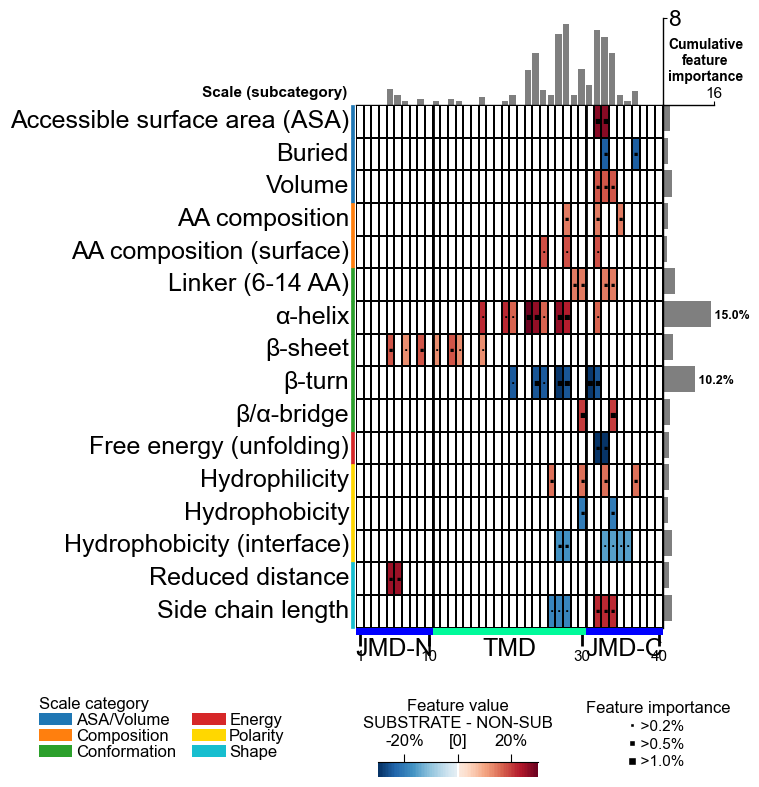

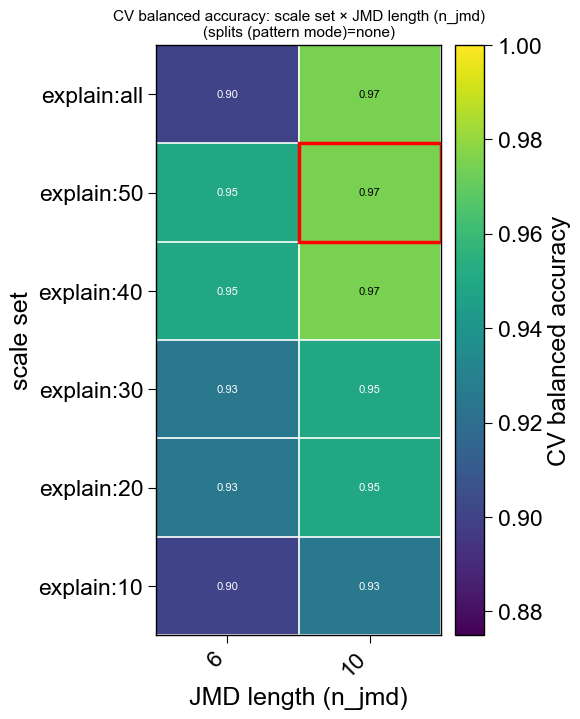

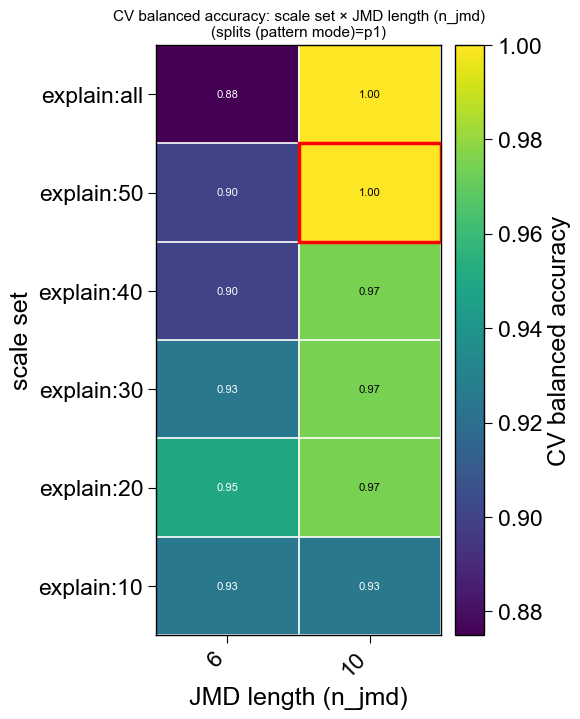

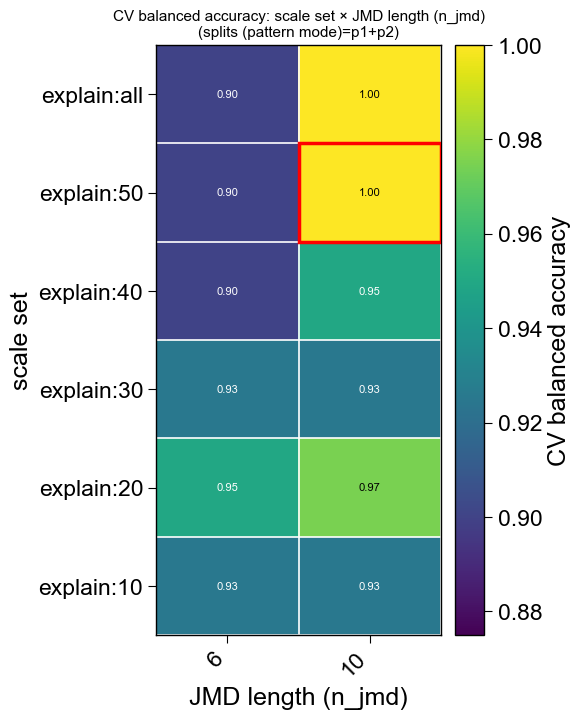

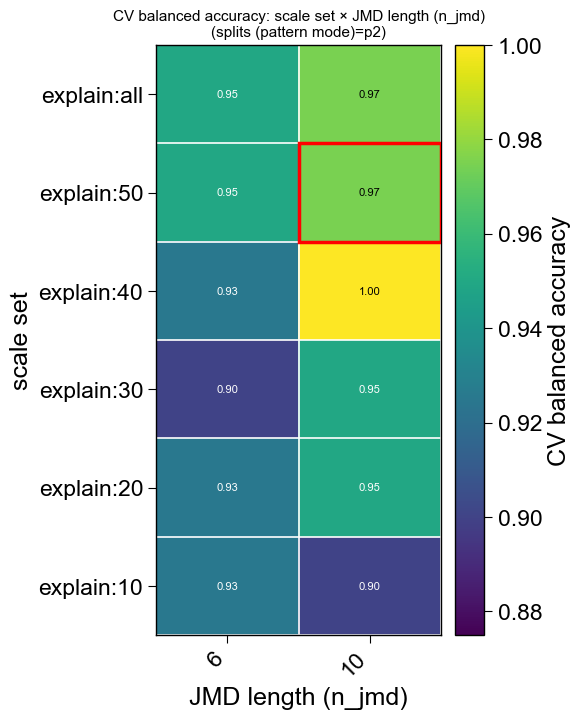

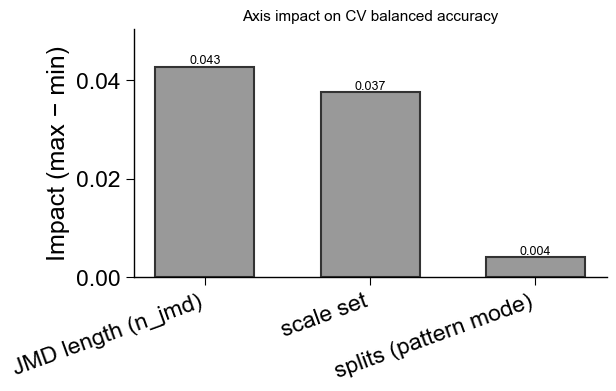

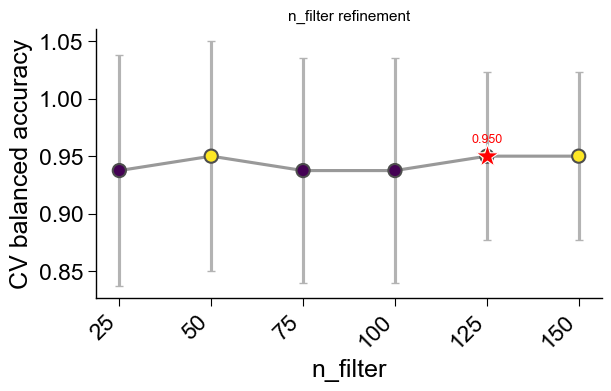

In [5]:
df_feat, ax, df_eval = aap.find_features(labels=labels, df_seq=df_seq, search="balanced",
                                         kws={"n_split_max": 15}, top_n=25, plot=True,
                                         name_test="SUBSTRATE", name_ref="NON-SUB",
                                         random_state=42, n_jobs=1)

print(f"feature map + {len(ax.eval)} publication eval figures (ax.eval)")
plt.show()

## Composition baselines

Set ``baselines`` to compare the positional CPP features against plain **composition** baselines — the *"how much does knowing the position add over a frequency count?"* question. ``baselines=True`` adds amino-acid composition (**AAC**, k=1) and dipeptide composition (**DPC**, k=2); a list of k-mer orders (1–4) selects others. Each baseline is cross-validated with the same ``model`` / ``cv`` / ``metric`` and appended to ``df_eval`` as a reference row (``stage="baseline"``, ``is_selected=False``); the returned winner stays the CPP feature set.

**AAC is a genuine CPP ``df_feat``** (a one-hot identity scale set with the whole-part ``Segment(1,1)`` split), so its feature map is drawn. **DPC / higher k-mers** cannot be per-residue Part-Split-Scale features, so they are drawn as composition **signal maps** (per-k-mer ``TEST − REF`` composition on the feature-map palette: a 20×20 first-vs-second-residue heatmap for k=2, top-N ranked bars for k≥3). All drawn objects are attached as ``ax.baselines`` (keyed ``AAC`` / ``DPC`` / ``<k>-mer``).

ax.baselines: ['AAC', 'DPC', '3-mer']


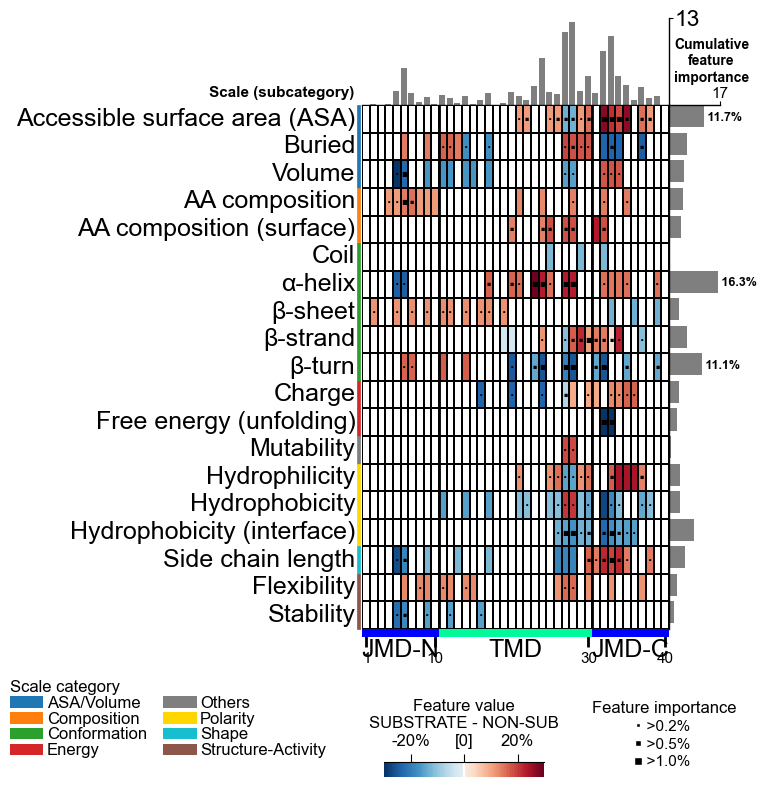

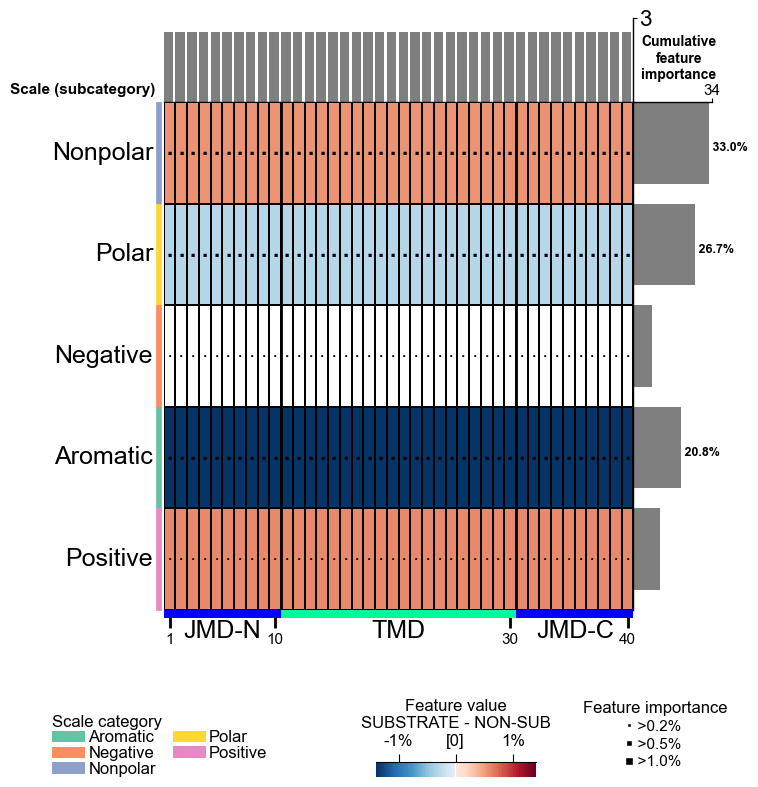

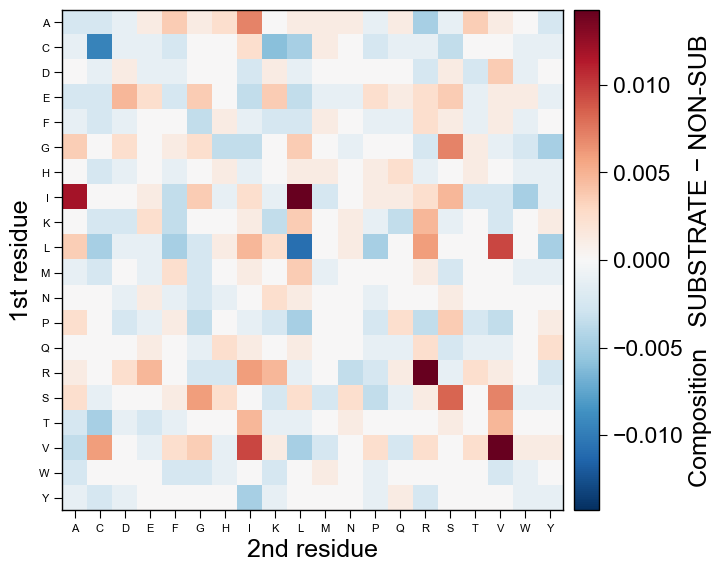

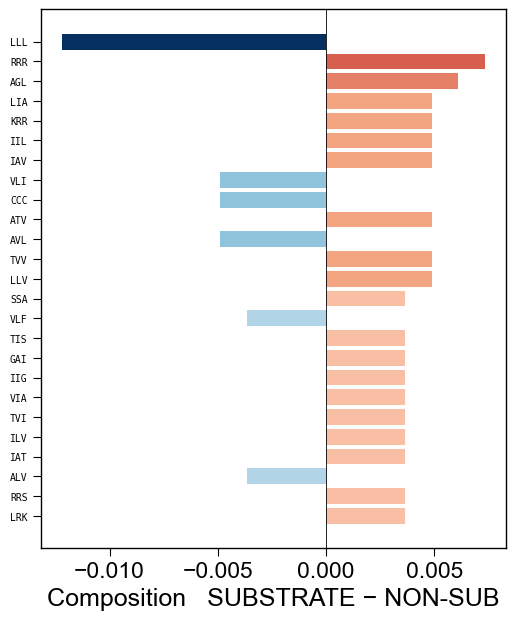

In [6]:
df_feat, ax, df_eval = aap.find_features(labels=labels, df_seq=df_seq, search="fast",
                                         baselines=[1, 2, 3], plot=True,
                                         name_test="SUBSTRATE", name_ref="NON-SUB",
                                         random_state=42, n_jobs=1)
print("ax.baselines:", list(ax.baselines))
plt.show()

The baseline rows appear in ``df_eval`` next to the CPP configurations, so the composition scores sit alongside the CPP winner's for a direct comparison:

In [7]:
cols = (["stage", "scale", "n_features"]
        + [c for c in df_eval.columns if c.endswith(("_mean", "_std"))]
        + ["is_selected"])
aa.display_df(df_eval[cols].round(3), n_rows=15, show_shape=True)

DataFrame shape: (4, 6)


,stage,scale,n_features,balanced_accuracy_mean,balanced_accuracy_std,is_selected
1,single,explain:30,81,0.950000,0.100000,True
2,baseline,AAC,20,0.725000,0.146000,False
3,baseline,DPC,400,0.600000,0.229000,False
4,baseline,3-mer,8000,0.525000,0.122000,False
